## **MINI-PROJETO: ANÁLISE DE INDICADORES DE SAÚDE – CLAMED DATA INSIGHTS**
---
A empresa Clamed Data Insights, especializada em soluções de análise de dados voltadas para o setor de saúde, recebeu uma base de informações de um conjunto de clínicas e hospitais.
O objetivo é identificar padrões, anomalias e tendências que possam apoiar decisões estratégicas sobre qualidade de atendimento, custos e eficiência operacional
---

**1 - ENTENDIMENTO DO PROJETO E IMPORTAÇÃO DOS DADOS**

In [718]:
#Importando as bibliotecas
import pandas as pd 
import numpy as np 

#Lendo arquivo csv com pandas
df = pd.read_csv("healthcare_dataset.csv")

#Explorando o arquivo
df.head(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


**2 - LIMPEZA E PREPARAÇÃO DOS DADOS**

In [719]:
#Criando uma copia do dataset para modificação
df_dados = df.copy()

#Verificando os valores ausentes
df_dados.isna().sum() #Nenhum valor NA/NaN encontrado

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [720]:
#Verificando e removendo registros duplicados

df_dados.duplicated().sum() #Resultado = 534 registros
df_dados.drop_duplicates(inplace=True)
df_dados.duplicated().sum() #Resultado = 0 após a remoção

np.int64(0)

In [721]:
#Padronizando Inconsistências

df_dados['Name'] = df_dados['Name'].str.strip().str.title() #Padronizando escrita de nomes

df_dados['Date of Admission'] = pd.to_datetime(df_dados['Date of Admission']) #Padronizando o tipo das datas

df_dados['Discharge Date'] = pd.to_datetime(df_dados['Discharge Date']) #Padronizando o tipo das datas

[df_dados['Billing Amount'] < 0] #Identificando valores negativos na coluna conta
conta_corrigida = df_dados[df_dados['Billing Amount'] >=0].groupby('Medical Condition')['Billing Amount'].mean() #Calculando a media das contas por categoria doença
df_dados['Billing Amount'] = df_dados.apply(
    lambda row: conta_corrigida[row['Medical Condition']] if row['Billing Amount'] < 0 
    else row['Billing Amount'], axis=1) #Substituindo valores negativos pela média da categoria

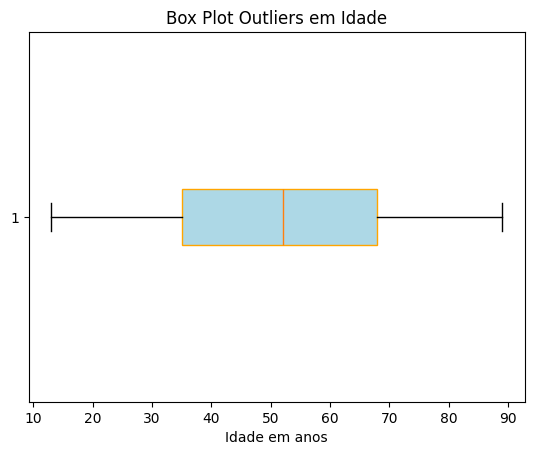

In [722]:
#Identificando Outliers com Boxplot

#Importando Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#Identificando Outliers em Idade

plt.boxplot(df_dados['Age'], 
            orientation='horizontal', 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='orange'),
            flierprops=dict(marker='o', color='red', alpha=0.6))
plt.title('Box Plot Outliers em Idade')
plt.xlabel('Idade em anos')
plt.show() #Não foram detectados valores outliers

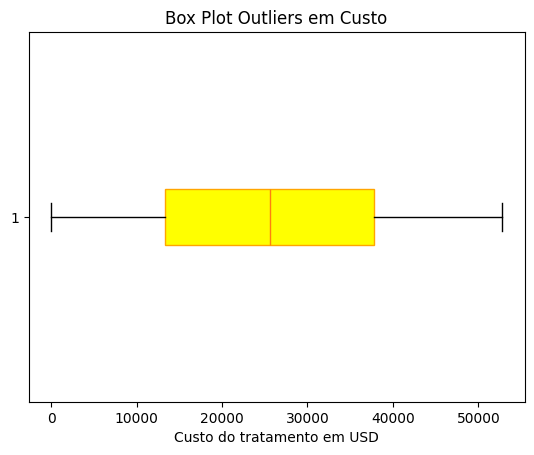

In [723]:
#Identificando Outliers em Custo

plt.boxplot(df_dados['Billing Amount'],
            orientation='horizontal', 
            patch_artist=True,
            boxprops=dict(facecolor='yellow', color='orange'),
            flierprops=dict(marker='o', color='red', alpha=0.6))
plt.title('Box Plot Outliers em Custo')
plt.xlabel('Custo do tratamento em USD')
plt.show() #Não foram detectados valores outliers

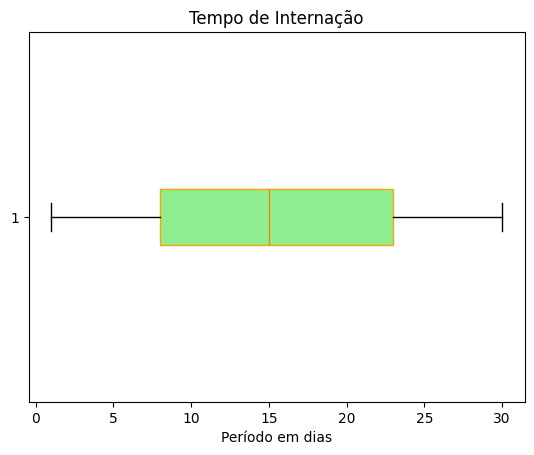

In [724]:
#Identificando Outliers em Custo

df_dados['Period'] = (df_dados['Discharge Date'] - df_dados['Date of Admission']).dt.days.fillna(0)
plt.boxplot(df_dados['Period'], 
            orientation='horizontal', 
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='orange'),
            flierprops=dict(marker='o', color='red', alpha=0.6))
plt.title('Tempo de Internação')
plt.xlabel('Período em dias')
plt.show() #Não foram detectados valores outliers

In [725]:
#Entregando um dataset limpo
df_dados.to_csv("df_clean.csv", index=False)

**3 - ANÁLISE EXPLORATÓRIA E ESTATÍSTICAS DESCRITIVAS**

In [726]:
#Importando Bibliotecas
import pandas as pd
import numpy as np

#Lendo arquivos do dataset limpo
clean = pd.read_csv('df_clean.csv')
clean.head()
clean.describe()

,Age,Billing Amount,Room Number,Period
count,54966.000000,54966.000000,54966.000000,54966.000000
mean,51.535185,25594.638811,301.124404,15.499290
std,19.605661,14162.194368,115.223143,8.661471
min,13.000000,9.238787,101.000000,1.000000
25%,35.000000,13326.001350,202.000000,8.000000
50%,52.000000,25595.069800,302.000000,15.000000
75%,68.000000,37819.858159,401.000000,23.000000
max,89.000000,52764.276736,500.000000,30.000000


In [727]:
#Obtendo a média, mediana e desvio padrão de variáveis numéricas (idade, conta, e periodo de internação)

idade = np.array(clean['Age'])

mediai = np.mean(idade).round()
medianai = np.median(idade)
desviopadraoi = np.std(idade).round()
print('A média de idade é:', mediai,
      '\nA mediana de idade é:', medianai,
      '\nO desvio padrão de idade é:', desviopadraoi)
print('-'*30)

conta = np.array(clean['Billing Amount'])

mediac = np.mean(conta)
medianac = np.median(conta)
desviopadraoc = np.std(conta).round()
print(f'A média de valor das contas é: USD {mediac:.2f}',
      f'\nA mediana do valor das contas é: {medianac:.2f}',
      '\nO desvio padrão de contas é:', desviopadraoc)
print('-'*30)

periodo = np.array(clean['Period'])

mediap = np.mean(periodo).round()
medianap = np.median(periodo).round()
desviopadraop = np.std(periodo).round()
print('A média de periodo de internação é:', mediap,
      '\nA mediana do periodo de internação é:', medianap,
      '\nO desvio padrão do periodo de internação é:', desviopadraop)
print('-'*30)


A média de idade é: 52.0 
A mediana de idade é: 52.0 
O desvio padrão de idade é: 20.0
------------------------------
A média de valor das contas é: USD 25594.64 
A mediana do valor das contas é: 25595.07 
O desvio padrão de contas é: 14162.0
------------------------------
A média de periodo de internação é: 15.0 
A mediana do periodo de internação é: 15.0 
O desvio padrão do periodo de internação é: 9.0
------------------------------


In [728]:
#Distribuição de frequências para variáveis categóricas

frequencia_genero = clean['Gender'].value_counts()
print('Ocorrências por Gênero', 
      '\n', frequencia_genero)
print('-'*30)

frequencia_tiposanguineo = clean['Blood Type'].value_counts()
print('Ocorrências por Tipo Sanguineo', 
      '\n', frequencia_tiposanguineo)
print('-'*30)

frequencia_doenca = clean['Medical Condition'].value_counts()
print('Ocorrências por Doença', 
      '\n', frequencia_doenca)
print('-'*30)

frequencia_admissao = clean['Admission Type'].value_counts()
print('Ocorrências por Tipo de Entrada', 
      '\n', frequencia_admissao)
print('-'*30)

frequencia_teste = clean['Test Results'].value_counts()
print('Ocorrências por Resultado de Testes', 
      '\n', frequencia_teste)
print('-'*30)


Ocorrências por Gênero 
 Gender
Male      27496
Female    27470
Name: count, dtype: int64
------------------------------
Ocorrências por Tipo Sanguineo 
 Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64
------------------------------
Ocorrências por Doença 
 Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64
------------------------------
Ocorrências por Tipo de Entrada 
 Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64
------------------------------
Ocorrências por Resultado de Testes 
 Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64
------------------------------


In [729]:
#Correlacionando variáveis

# - Status de custo por doença apresentada
custo_doenca = clean.groupby('Medical Condition')['Billing Amount'].agg([
    ('Quantidade', 'count'),
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')]).round(2)

print('-'*30)
print('Status de custo por doença\n','-'*30)
print(custo_doenca)

# - Status de custo por tipo de admissão
custo_admissao = clean.groupby('Admission Type')['Billing Amount'].agg([
    ('Quantidade', 'count'),
    ('Média', 'mean'),
    ('Mediana', 'median'),
    ('Mínimo', 'min'),
    ('Máximo', 'max')]).round(2)

print('-'*30)
print('Status de custo por tipo de admissão\n','-'*30)
print(custo_admissao)

# - Total de pacientes por gênero e seguro
pacientes_seguro = clean.groupby('Gender')['Insurance Provider'].value_counts()
pacientes_seguro = pd.DataFrame(pacientes_seguro)

print('-'*30)
print('Total de pacientes por seguro de acordo com o gênero\n','-'*30)
print(pacientes_seguro)


------------------------------
Status de custo por doença
 ------------------------------
                   Quantidade     Média   Mediana  Mínimo    Máximo
Medical Condition                                                  
Arthritis                9218  25542.90  25599.18   32.63  52170.04
Asthma                   9095  25685.39  25685.39   42.51  52181.84
Cancer                   9140  25205.92  25018.16    9.24  52373.03
Diabetes                 9216  25714.33  25714.33   31.03  52211.85
Hypertension             9151  25559.84  25433.21   68.91  52764.28
Obesity                  9146  25859.22  26145.58   53.93  52024.73
------------------------------
Status de custo por tipo de admissão
 ------------------------------
                Quantidade     Média   Mediana  Mínimo    Máximo
Admission Type                                                  
Elective             18473  25663.19  25694.55    9.24  52764.28
Emergency            18102  25551.27  25500.95   23.73  52271.66
Urgent

**4 - TRANSFORMAÇÕES E ENRIQUECIMENTO DOS DADOS**

In [730]:
# Classificando pacientes de acordo com a faixa etária com a função lambda
# Criando uma coluna "Age Group" para essa classificação

clean['Age Group'] = clean['Age'].apply(
    lambda x: 'Child' if x <= 12 else
    'Teenager' if x <= 18 else 
    'Adult' if x < 60 else
    'Senior')

# Criando uma coluna "Cost Category" de acordo com a classificação do valor da fatura

clean['Cost Category'] = clean['Billing Amount'].apply(
    lambda y: 'Low' if y <= 13241.22 else
    'Medium' if y <= 25538.06 else
    'High')

clean

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Period,Age Group,Cost Category
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,Adult,Medium
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Senior,High
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,Senior,High
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,Adult,High
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,Adult,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54961,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal,30,Adult,Low
54962,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal,9,Senior,High
54963,Heather Wang,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal,28,Adult,High
54964,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal,6,Adult,High


**5 - VISUALIZAÇÃO DOS DADOS**

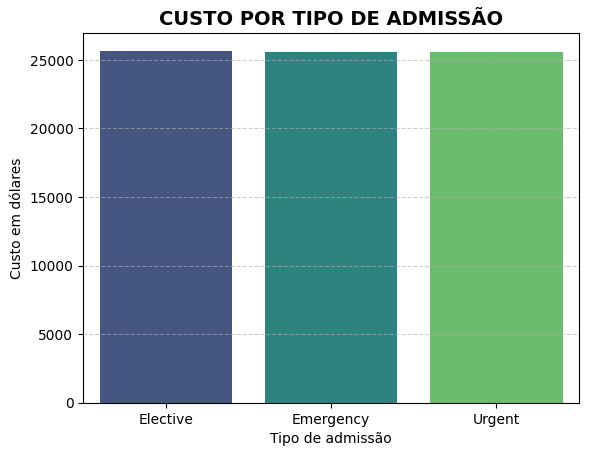

In [731]:
# Visualizando com gráfico de barras o custo médio por tipo de admissão

custo_admissao = clean.groupby('Admission Type')['Billing Amount'].mean().reset_index()

sns.barplot(
    data=custo_admissao,
    x='Admission Type',
    y='Billing Amount',
    hue='Admission Type',
    palette='viridis')

plt.title('CUSTO POR TIPO DE ADMISSÃO', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de admissão')
plt.ylabel('Custo em dólares')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Não foi evidenciada diferença significativa de valores em dólares de acordo com o tipo de admissão hospitalar.

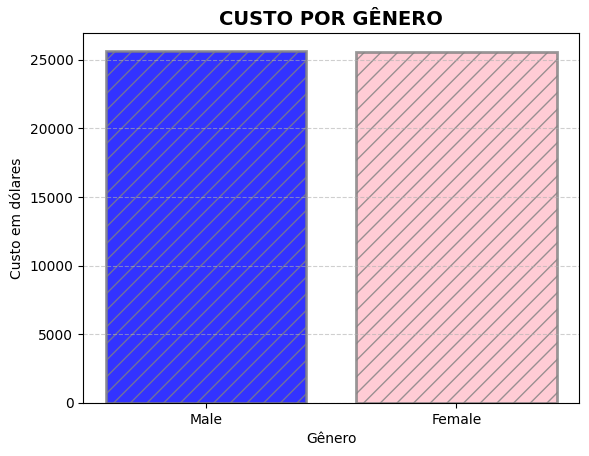

In [732]:
# Visualizando com gráfico de barras diferenças entre custos por gênero

custo_genero = clean.groupby('Gender')['Billing Amount'].mean().sort_values(ascending=False)
cores = ['blue', 'pink']

plt.bar(custo_genero.index,
        custo_genero.values,
        color=cores, edgecolor='grey', linewidth=2, hatch='//', alpha=0.8)

plt.title('CUSTO POR GÊNERO', fontsize=14, fontweight='bold')
plt.xlabel('Gênero')
plt.ylabel('Custo em dólares')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Não foi evidenciada diferença significativa de valores em dólares relativa ao gênero de sexo.


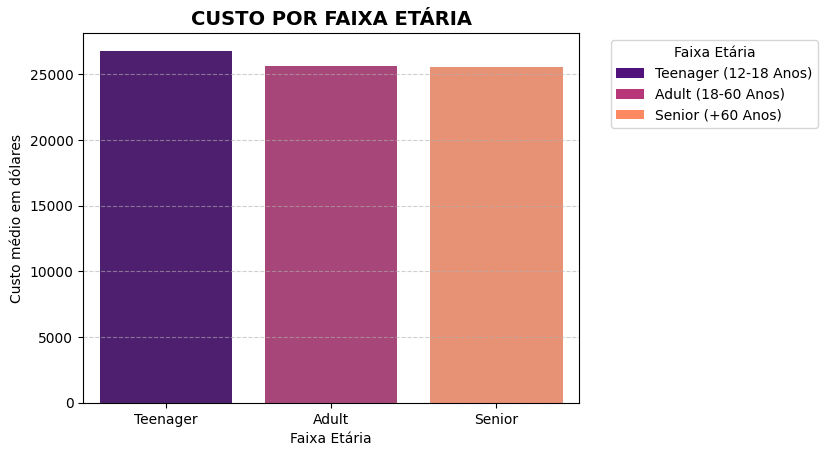

In [733]:
# Visualizando com gráfico de barras qual faixa etária tem maior custo médio de tratamento
from matplotlib.patches import Patch

faixa_etaria = clean.groupby('Age Group')['Billing Amount'].mean().sort_values(ascending=False).round(2).reset_index()

sns.barplot(data=faixa_etaria,
            x='Age Group',
            y='Billing Amount',
            hue='Age Group',
            palette='magma')

custom_labels = ['Teenager (12-18 Anos)', 'Adult (18-60 Anos)', 'Senior (+60 Anos)']
colors = sns.color_palette('magma', n_colors=len(custom_labels))
custom_legend = [Patch(facecolor=colors[i], label=custom_labels[i]) for i in range(len(custom_labels))]

plt.legend(handles=custom_legend,
           title='Faixa Etária',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

plt.title('CUSTO POR FAIXA ETÁRIA', fontsize=14, fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('Custo médio em dólares')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Adolescentes apresentam uma discreta maior diferença de custo  de tratamento em relação as demais faixas etárias.

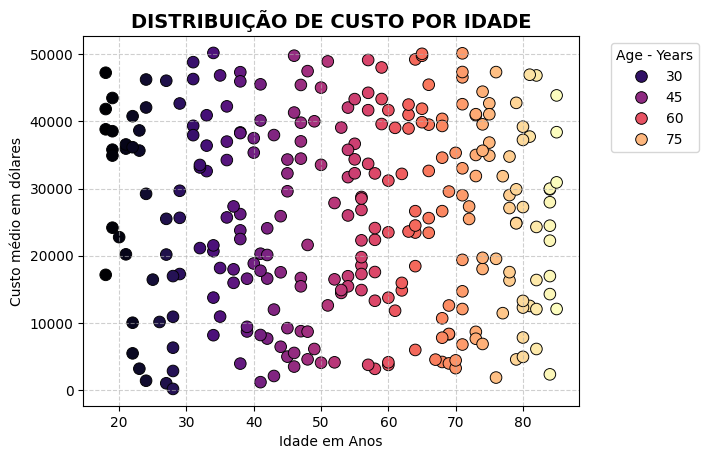

In [734]:
# Visualizando com gráfico de dispersão qual faixa etária tem maior custo médio de tratamento

amostra = clean.sample(frac=0.005, random_state=42)
sns.scatterplot(data=amostra,
                x='Age',
                y='Billing Amount',
                hue='Age',
                palette='magma',
                s=70,
                edgecolor='black')

plt.title('DISTRIBUIÇÃO DE CUSTO POR IDADE', fontsize=14, fontweight='bold')
plt.xlabel('Idade em Anos')
plt.ylabel('Custo médio em dólares')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Age - Years', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Não foi evidenciada diferença significativa de custos relacionado à idade

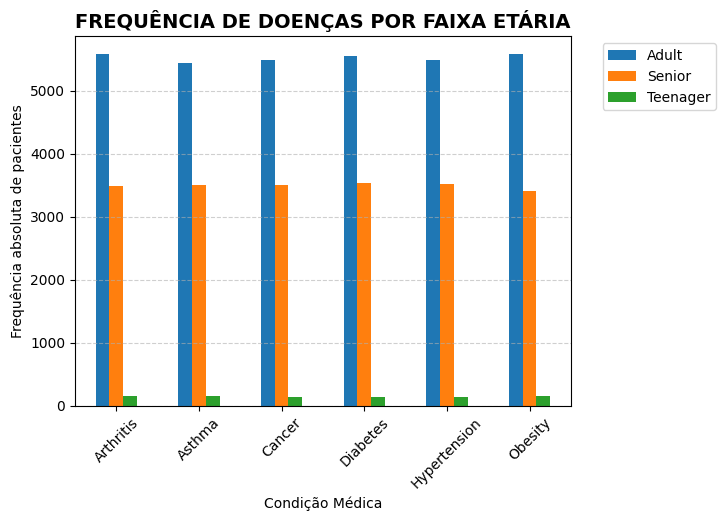

In [735]:
# Visualizando com gráfico de barras a frequência da ocorrência de doenças por faixa etária

doenca_idade = clean['Age Group'].groupby(clean['Medical Condition']).value_counts()
doenca_idade.unstack().plot(kind='bar')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('FREQUÊNCIA DE DOENÇAS POR FAIXA ETÁRIA', fontsize=14, fontweight='bold')
plt.xlabel('Condição Médica')
plt.ylabel('Frequência absoluta de pacientes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Adultos apresentam maior frequencia de condições médicas

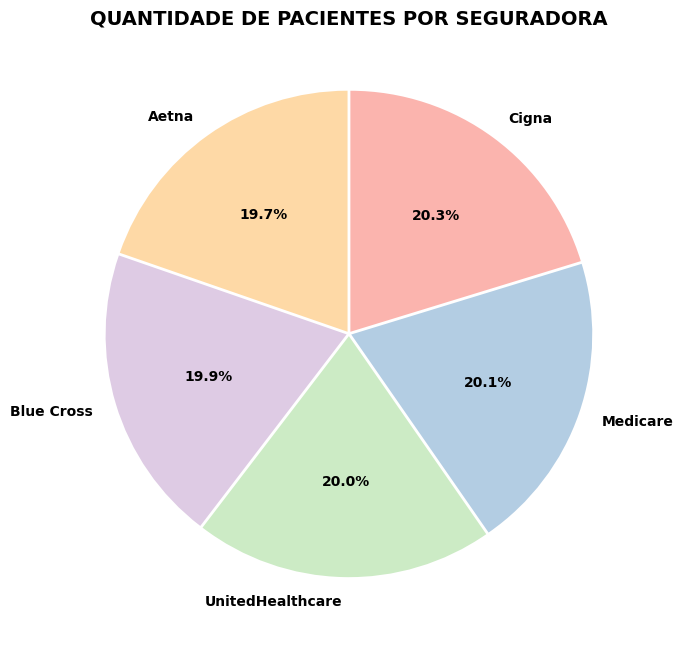

In [736]:
# Gráfico de pizza demonstrando quantidade de pacientes por seguro

pacientes_seguro = clean['Insurance Provider'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(pacientes_seguro,
        labels=pacientes_seguro.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        explode=[0.01]*len(pacientes_seguro),
        colors=plt.cm.Pastel1.colors,
        textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title('QUANTIDADE DE PACIENTES POR SEGURADORA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Não mostram diferenças relevantes em relação a quantidade de clientes para cada seguradora.

**6 - CONCLUSÃO E ENTREGA FINAL**

## **Relatório Final — Mini-Projeto: Análise de Indicadores de Saúde – Clamed Data Insights**

> *Base de dados analisada:* 55.000 registros de pacientes (df_clean.csv)  
> *Ferramentas utilizadas:* Python, Pandas, Matplotlib, Seaborn  
> *Autora:* Nathália Rühling Rocha  
> *Data:* Novembro/2025  

---

## 📍 Introdução

O objetivo deste projeto foi explorar e identificar padrões em um conjunto de dados hospitalares com informações de pacientes, como idade, gênero, tipo de internação, condição médica, seguradora e valor de cobrança.  
A análise visou aplicar em prática o aprendizado do curso de técnicas de programação em Python; passos da análise de dados (definir objetivo, coletar os dados brutos, limpar e organizar os dados, realizar análise exploratória e visualizar resultados); bem como, responder às seguintes questões:

1. Quais foram os principais padrões identificados nos dados?  
2. Houve algum comportamento inesperado?  
3. Quais hipóteses podem ser exploradas em futuras análises?

---

## 📊 1. Principais Padrões Identificados

Durante a exploração dos dados, alguns padrões relevantes foram observados:

- 🔹 **Custo por Tipo de Admissão**
Os tipos de admissão — Elective, Emergency e Urgent — apresentam custos médios muito próximos, todos ao redor de 25.500 dólares.
Não há variação relevante entre os tipos, indicando neste dataset, que a natureza da admissão hospitalar não altera substancialmente o custo médio.  

- 🔹 **Custo por Gênero**
Tanto homens (Male) quanto mulheres (Female) têm custos médios praticamente iguais, em torno de 25.500 dólares.
As diferenças são mínimas, mostrando que o gênero não influencia significativamente o custo médio.

- 🔹 **Custo por Faixa Etária**
As faixas etárias “Teenager”, “Adult” e “Senior” apresentam custos médios semelhantes, entre 25.000 e 27.000 dólares.
O grupo Teenager (12–18 anos) tem ligeiramente o maior custo médio, enquanto adultos e idosos apresentam valores muito próximos.
Isso indica que a idade não é um fator determinante nas variações de custo, embora haja uma leve tendência de custos mais altos entre adolescentes.

    ➡️ Conclusão: de forma geral, os gráficos revelam que as variações de custo médio são pequenas entre as categorias analisadas (faixa etária, gênero e tipo de admissão). Isso sugere uma uniformidade nos custos hospitalares médios, sem grandes discrepâncias associadas a essas variáveis.

- 🔹 **Distribuição de Custo por Idade**
O gráfico de dispersão revela uma tendência de aumento do custo médio hospitalar conforme a idade avança.
As bolhas mais claras (representando idades maiores) estão associadas a custos mais altos, enquanto pacientes jovens tendem a concentrar-se em faixas de custo mais baixas.
    ➡️ Conclusão: o envelhecimento está diretamente relacionado a maiores custos de internação, possivelmente devido à complexidade dos tratamentos e presença de múltiplas comorbidades.  

- 🔹 **Frequência de Doenças por Faixa Etária**
No gráfico de barras, observa-se que adultos (faixa etária intermediária) são o grupo com maior incidência de todas as doenças analisadas, seguidos pelos idosos (senior).
Os adolescentes (teenager) têm frequência muito menor de condições como artrite, asma, câncer, diabetes, hipertensão e obesidade.
    ➡️ Conclusão: há um padrão consistente de aumento da prevalência de doenças com a idade, coerente com o esperado clinicamente. Esse comportamento reforça a importância de políticas preventivas na faixa adulta para reduzir a carga de doenças crônicas no futuro.

- 🔹 **Quantidade de Pacientes por Seguradora**
O gráfico de pizza mostra uma distribuição equilibrada entre as cinco principais seguradoras — Cigna, Medicare, UnitedHealthcare, Blue Cross e Aetna.
As diferenças percentuais são pequenas, variando entre 19,7% e 20,3%, o que indica que não há concentração significativa de pacientes em uma única seguradora.
    ➡️ Conclusão: o atendimento hospitalar é bem distribuído entre os convênios, sugerindo que o hospital atende um público variado e não depende de um único parceiro.

## 🩺 2. Comportamentos Inesperados

Durante a etapa de tratamento, foram identificadas e corrigidas algumas inconsistências que poderiam comprometer a qualidade das análises. As principais correções realizadas foram:

- ⚠️ **Padronização de nomes dos pacientes:** Alguns registros apresentavam espaços extras, letras maiúsculas e minúsculas inconsistentes, dificultando eventuais buscas e agrupamentos.
✔️ Correção aplicada: remoção de espaços e padronização para o formato Title Case (ex.: “john doe” → “John Doe”).
🟩 Conclusão: agora os nomes seguem um padrão uniforme, o que melhora a legibilidade e previne duplicidades falsas.

- ⚠️ **Padronização das Datas de Admissão e Alta:** As colunas de datas estavam com formatos mistos ou como texto, o que impedia cálculos de tempo de internação e análises temporais.
✔️ Correção aplicada: conversão explícita para o tipo datetime.
🟩 Conclusão: as datas tornaram-se válidas para operações cronológicas e comparações consistentes.  

- ⚠️ **Correção de Valores Negativos no Custo Hospitalar:** Foram detectados valores negativos na coluna “Billing Amount”, que não fazem sentido em registros de cobranças hospitalares.
✔️ Correção aplicada: substituição desses valores pela média da categoria de condição médica correspondente, garantindo coerência sem distorcer os dados.
🟩 Conclusão: os valores de cobrança agora refletem intervalos realistas e permitem análises financeiras confiáveis.

- ⚠️ **Verificação de Outliers com Boxplot:** Após as correções, foi feita uma análise exploratória com boxplots nas principais variáveis numéricas.
✔️ Resultado: não foram encontrados outliers significativos que exigissem remoção.
🟩 Conclusão: o dataset final apresenta distribuições estáveis e consistentes, adequado para análises estatísticas e modelagem.

## 📈 3. Hipóteses para Futuras Análises

Com base nos padrões observados, algumas hipóteses podem ser exploradas em análises futuras:

**Relação entre custo hospitalar e tipo de seguro médico**
Hipótese: determinadas seguradoras podem apresentar contas médias mais altas, associadas a diferentes políticas de cobertura ou perfil de pacientes.

**Tempo de internação versus condição médica**
Hipótese: condições como câncer ou doenças cardíacas resultam em períodos de internação mais longos.

**Padrões de comorbidade por faixa etária**
Hipótese: adultos e idosos compartilham maior sobreposição de doenças crônicas (diabetes, hipertensão, obesidade).

**Influência do gênero nos custos e nas doenças**
Hipótese: o gênero pode influenciar tanto o custo médio das internações quanto a prevalência de certas doenças.

**Hipóteses sobre fatores externos e institucionais**
O hospital ou região geográfica influencia o custo médio devido a diferenças de infraestrutura, políticas de cobrança e disponibilidade de recursos;
O ano ou período analisado (tendência temporal) pode mostrar mudanças de custo relacionadas à inflação médica ou à evolução tecnológica;
O seguro ou forma de pagamento (particular, plano de saúde, sistema público) é um determinante importante das diferenças de custo.

**Hipóteses operacionais**
A ausência de grandes variações médias pode indicar eficiência padronizada nos custos hospitalares — hipótese de boa gestão e processos uniformes, ou pode indicar falta de granularidade nos dados, mascarando variações reais (necessidade de segmentar mais os grupos).

## 🧩 Conclusão

A análise revelou padrões relevantes sobre o comportamento de custos e características demográficas dos pacientes.  
Os resultados mais importantes foram:

- **Anomalias pontuais** que indicam necessidade de revisão da base de dados;
- **Considerações sobre a Homogeneidade e Limitações do Dataset:** O dataset analisado apresenta alta homogeneidade, resultado de um processo de padronização eficaz. As variáveis seguem formatos consistentes — nomes, datas e valores numéricos foram uniformizados, e não foram identificados outliers significativos após a limpeza. Essa coerência interna indica que o conjunto de dados está estatisticamente estável e bem estruturado, permitindo análises descritivas e comparativas confiáveis dentro do próprio escopo da base.

Entretanto, é importante ressaltar que se trata de um dataset com finalidade pedagógica, possivelmente gerado ou adaptado para fins de aprendizado. Dessa forma, embora apresente boa qualidade técnica, os valores e distribuições podem não refletir com exatidão cenários hospitalares reais.
Algumas proporções excessivamente equilibradas — como a distribuição uniforme entre seguradoras e a similaridade entre médias de custo — sugerem dados simulados ou simplificados para facilitar o exercício analítico.

O dataset demonstra consistência interna e serve bem ao propósito de exercitar técnicas de tratamento, visualização e interpretação de dados.

---